#### Библиотеки

In [1]:
import sys

sys.path.append("..")

import warnings

import pandas as pd
import torch
import numpy as np

import os
import gc

from distilrl.utils.misc import seed_everything
from distilrl.constants import CONFIG_DIR
from pathlib import Path

from SMPyBandits.Arms import Bernoulli
from SMPyBandits.Environment import Evaluator

from hydra.utils import instantiate, get_class
from datasets import Dataset

warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2
%cd ..

device = "cuda" if torch.cuda.is_available() else "cpu"
device

If you want the speed up brought by numba.jit, try to manually install numba and check that it works (installing llvmlite can be tricky, cf. https://github.com/numba/numba#custom-python-environments
Info: Using the Jupyter notebook version of the tqdm() decorator, tqdm_notebook() ...
If you want the speed up brought by numba.jit, try to manually install numba and check that it works (installing llvmlite can be tricky, cf. https://github.com/numba/numba#custom-python-environments
/home/ivanov.dko/projects/distilrl


'cpu'

Я решил начать с максимально простого сетапа - многоруких бандитов. В статье отдельно оговаривается, что они всё тестили на adversarial bandits, я же взял обычных стохастических. Итого эксперимент будем строить так:

1. Зададим какого-то многорукого бандита с числом рук $n$ и числом шагов $N$. В статье взяты $n=10$ и $N=20000$, я возьму точно так же. Конкретные распределения рук, функция изменения и прочее там не указаны (либо я проглядел), так что тут у нас свобода
2. Я лично взял руки из $Ber(p)$, где само $p$ мы тоже берём как-то случайно. Я рискну предположить, что именно такое же они и брали, потому что на графиках средний reward не превышает 1
3. Важно ещё, что они тестили эту штуку следующим образом. На трейне у всех нечётных ручек вероятность больше, на тесте - равномерно, либо больше у чётных, это тоже смоделируем
4. Стейтов у бандитов нет, поэтому они нам не нужны, их собирать не будем. Мб как-то можно обойти, либо я опять же не совсем понял, что они подразумевают под этим
5. Я буду использовать несколько алгоритмов решения, чтобы было чуть поинтереснее. В статье берут UCB, я возьму ещё 5

Собираем по итогу двойки $(a_i, r_i)$, по ним будем учиться предсказывать $a_{i+1}$, но чисто из интереса буду так же подсчитывать $(r | a_{i+1})$ и сравнивать с настоящим $r_{i+1}$, так что их тоже берём.        
И ещё нужны позиционные эмбеддинги, куда же без них, их тоже лучше собрать здесь, потому что у нас есть разные полиси. Важно, чтобы интервалы из разных полиси не пересекались, это я тоже учёл

Я использовал библиотеку `SMPyBandits`, потому что не хотелось изобретать велосипед, но по-хорошему нужно. Я не видел альтернатив, кроме `genrl`, но он у меня не ставится, так что работаем с тем, что есть

In [145]:
from omegaconf import OmegaConf

env_cfg, arm_cfg, policies_cfg = [
    OmegaConf.to_container(
    OmegaConf.load(Path(CONFIG_DIR, f"bandit/{cfg}.yaml"))
) for cfg in ["env", "arm", "policies"]]

У меня всё собрано в отдельных конфигах, чтобы было удобнее редактировать. И по-хорошему достаточно запустить скрипт. Это я оставляю скорее, как часть отчёта, тут мы поподробнее рассмотрим, а что вообще происходит. Конфиги в целом как я сказал, просто лишний раз удостоверимся

In [146]:
arm_cfg["arm_type"] = get_class(arm_cfg["arm_type"])
arm_cfg

{'arm_type': SMPyBandits.Arms.Bernoulli.Bernoulli}

In [147]:
policies_cfg

{'discounted_thompson': {'archtype': 'SMPyBandits.Policies.DiscountedThompson',
  'params': {'gamma': 0.95, 'alpha': 1}},
 'discounted_klucb': {'archtype': 'SMPyBandits.Policies.DiscountedklUCB',
  'params': {'gamma': 0.95}},
 'klucb': {'archtype': 'SMPyBandits.Policies.klUCB', 'params': {}},
 'ucbalpha': {'archtype': 'SMPyBandits.Policies.UCBalpha',
  'params': {'alpha': 0.5}},
 'emp_means': {'archtype': 'SMPyBandits.Policies.EmpiricalMeans',
  'params': {}},
 'exp3': {'archtype': 'SMPyBandits.Policies.Exp3', 'params': {'gamma': 0.01}}}

In [6]:
env_cfg

{'horizon': 20000, 'repetitions': 1, 'n_jobs': -1, 'verbosity': 1}

In [148]:
n_arms = 10
n_runs = 100

Распределения я сгенерирую отдельно для каждого бандита, потому что ручками это делать болезненно. Там ничего хитрого - начинаем с 0 и 1, 1 там, где избранные индексы, смотря трейн у нас или нет. Затем каждый из них я двигаю к 0.5, но так, чтобы избранные индексы были гарантированно больше. Плюс в статье есть 5% выборки, которые равномерны всегда, это мы тоже смоделируем

In [149]:
def generate_arm_dist(n_runs, n_arms, strategy="odd", mishap_chance=0.05, debug=True):
    
    assert n_arms % 2 == 0
    mishap = np.random.randint(0, 100, (n_runs,)) <= mishap_chance * 100
    
    if strategy in ["odd", "even"]:
        probas = torch.zeros(n_runs, n_arms)
        probas[:, ::2] = 1
        probas[:, ::2] += torch.FloatTensor(n_runs, n_arms // 2).uniform_(-0.5, 0)
        probas[:, 1::2] += torch.FloatTensor(n_runs, n_arms // 2).uniform_(0, 0.5)
        if strategy == "odd":
            probas = 1 - probas
    elif strategy == "uniform":
        probas = torch.FloatTensor(n_runs, n_arms).uniform_(0, 1)
    probas[mishap] = torch.FloatTensor(mishap.sum(), n_arms).uniform_(0, 1)
    if debug:
        print("Sampled uniform", mishap.sum(), "times")
        print(probas[mishap])

    return probas.numpy()

In [150]:
seed_everything(7)

odd_set, even_set, uniform_set = [generate_arm_dist(n_arms=n_arms, n_runs=n_runs, strategy=strategy) for strategy in ["odd", "even", "uniform"]]

Sampled uniform 5 times
tensor([[0.9420, 0.7568, 0.2651, 0.4055, 0.5469, 0.9826, 0.0819, 0.3799, 0.0731,
         0.6862],
        [0.4346, 0.2762, 0.0428, 0.3352, 0.0671, 0.6674, 0.0448, 0.2438, 0.9990,
         0.0170],
        [0.0886, 0.1166, 0.1794, 0.8957, 0.3394, 0.1136, 0.7819, 0.9355, 0.7483,
         0.5468],
        [0.5933, 0.6932, 0.9421, 0.7867, 0.1104, 0.1123, 0.1850, 0.2821, 0.9435,
         0.0017],
        [0.4272, 0.8790, 0.6904, 0.2454, 0.4941, 0.0931, 0.1819, 0.0828, 0.1347,
         0.9842]])
Sampled uniform 5 times
tensor([[0.5012, 0.0238, 0.1391, 0.1248, 0.8337, 0.8077, 0.5115, 0.1992, 0.2881,
         0.2136],
        [0.9631, 0.1064, 0.5894, 0.7198, 0.0710, 0.7110, 0.7488, 0.6281, 0.9648,
         0.2692],
        [0.0376, 0.2031, 0.0426, 0.6623, 0.6221, 0.2713, 0.3279, 0.7896, 0.5010,
         0.9181],
        [0.3085, 0.5680, 0.6247, 0.3227, 0.8743, 0.3566, 0.6497, 0.0970, 0.6241,
         0.8457],
        [0.0295, 0.9993, 0.5375, 0.9826, 0.8236, 0.7732, 0.4

Как видно, сгенерировалось всё хорошо

In [143]:
odd_set[:3]

array([[0.2325387 , 0.8930516 , 0.4005984 , 0.954561  , 0.17039418,
        0.6715442 , 0.17155486, 0.81479776, 0.3836192 , 0.663344  ],
       [0.28746927, 0.65066   , 0.39645696, 0.5273794 , 0.18513179,
        0.60146517, 0.31734192, 0.98501253, 0.07436585, 0.951473  ],
       [0.07252842, 0.5496294 , 0.22453237, 0.96241575, 0.3565805 ,
        0.597196  , 0.39684033, 0.90236497, 0.2774549 , 0.5493965 ]],
      dtype=float32)

Далее нужно немножко закостылить массив из полиси, потому что синтаксис у бибилиотеки своеобразный

In [151]:
policies = list(policies_cfg.values())
for policy in policies:
    policy["archtype"] = get_class(policy["archtype"])

Затем раскидать нужные вероятности по рукам и склеить

In [153]:
envs = [{"arm_type": arm, "params": params} for arm, params in zip([arm_cfg["arm_type"] for _ in range(n_runs)], odd_set)]

In [14]:
env_cfg["environment"] = envs
env_cfg["policies"] = policies

Накоец можно запускать процесс обучения, но предупреждаю, там будет много ненужных аутпутов

In [ ]:
# %%capture
seed_everything(42)

evaluator = Evaluator(env_cfg)
for idx, env in enumerate(evaluator.envs):
    evaluator.startOneEnv(idx, env)

Заодно посмотрим, какие алгоритмы справились лучше всего. На самом деле там всё чуть-чуть по-разному каждый раз, но во всяком случае они учатся хоть чему-то. Значит гипотетически мы тоже научимся


Giving the final ranks ...

Final ranking for this environment #0 : (using less accurate estimate of the regret)
- Policy 'EmpiricalMeans'	was ranked	1 / 6 for this simulation
	(last regret = 7.3318,	total regret = 7.3318,	total reward = 17440,	total weighted selection = 17408).
- Policy 'UCB($\alpha=0.5$)'	was ranked	2 / 6 for this simulation
	(last regret = 29.913,	total regret = 29.913,	total reward = 17326,	total weighted selection = 17386).
- Policy 'kl-UCB'	was ranked	3 / 6 for this simulation
	(last regret = 84.01,	total regret = 84.01,	total reward = 17270,	total weighted selection = 17332).
- Policy 'D-klUCB($\gamma=0.95$)'	was ranked	4 / 6 for this simulation
	(last regret = 1205.7,	total regret = 1208.7,	total reward = 16328,	total weighted selection = 16207).
- Policy 'Exp3($\gamma: 0.01$)'	was ranked	5 / 6 for this simulation
	(last regret = 2380.9,	total regret = 2382.2,	total reward = 15024,	total weighted selection = 15033).
- Policy 'DiscountedThompson($\gamma=0.95$)'

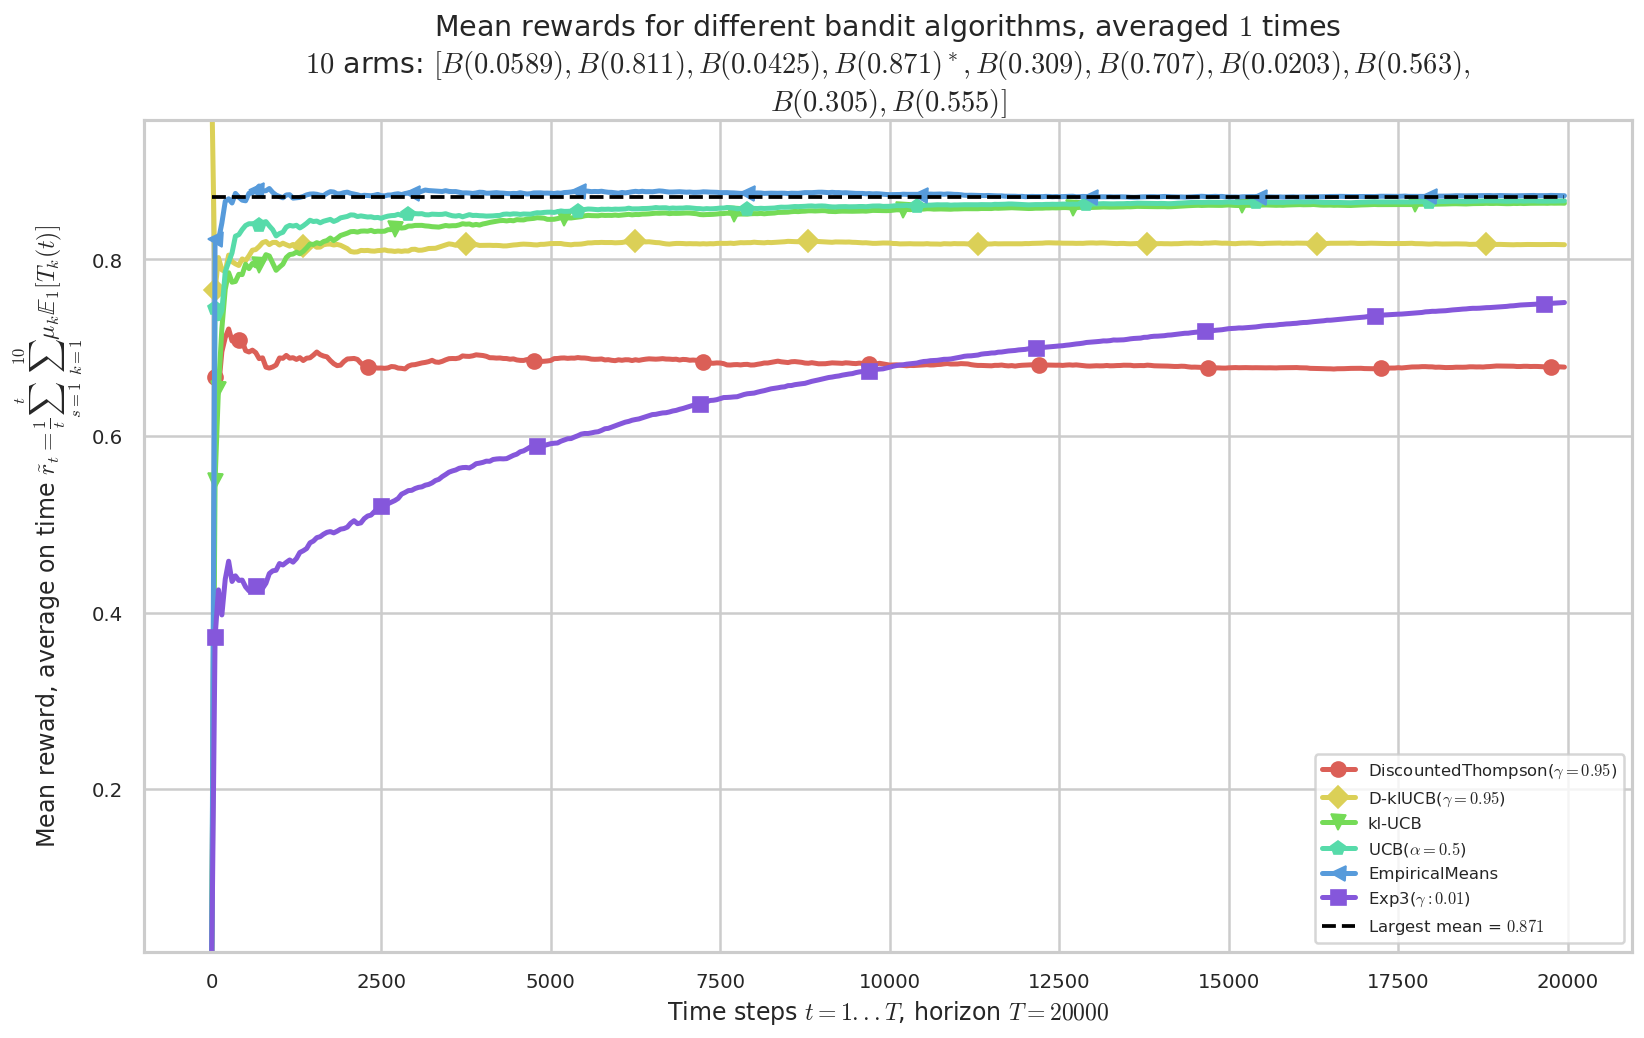

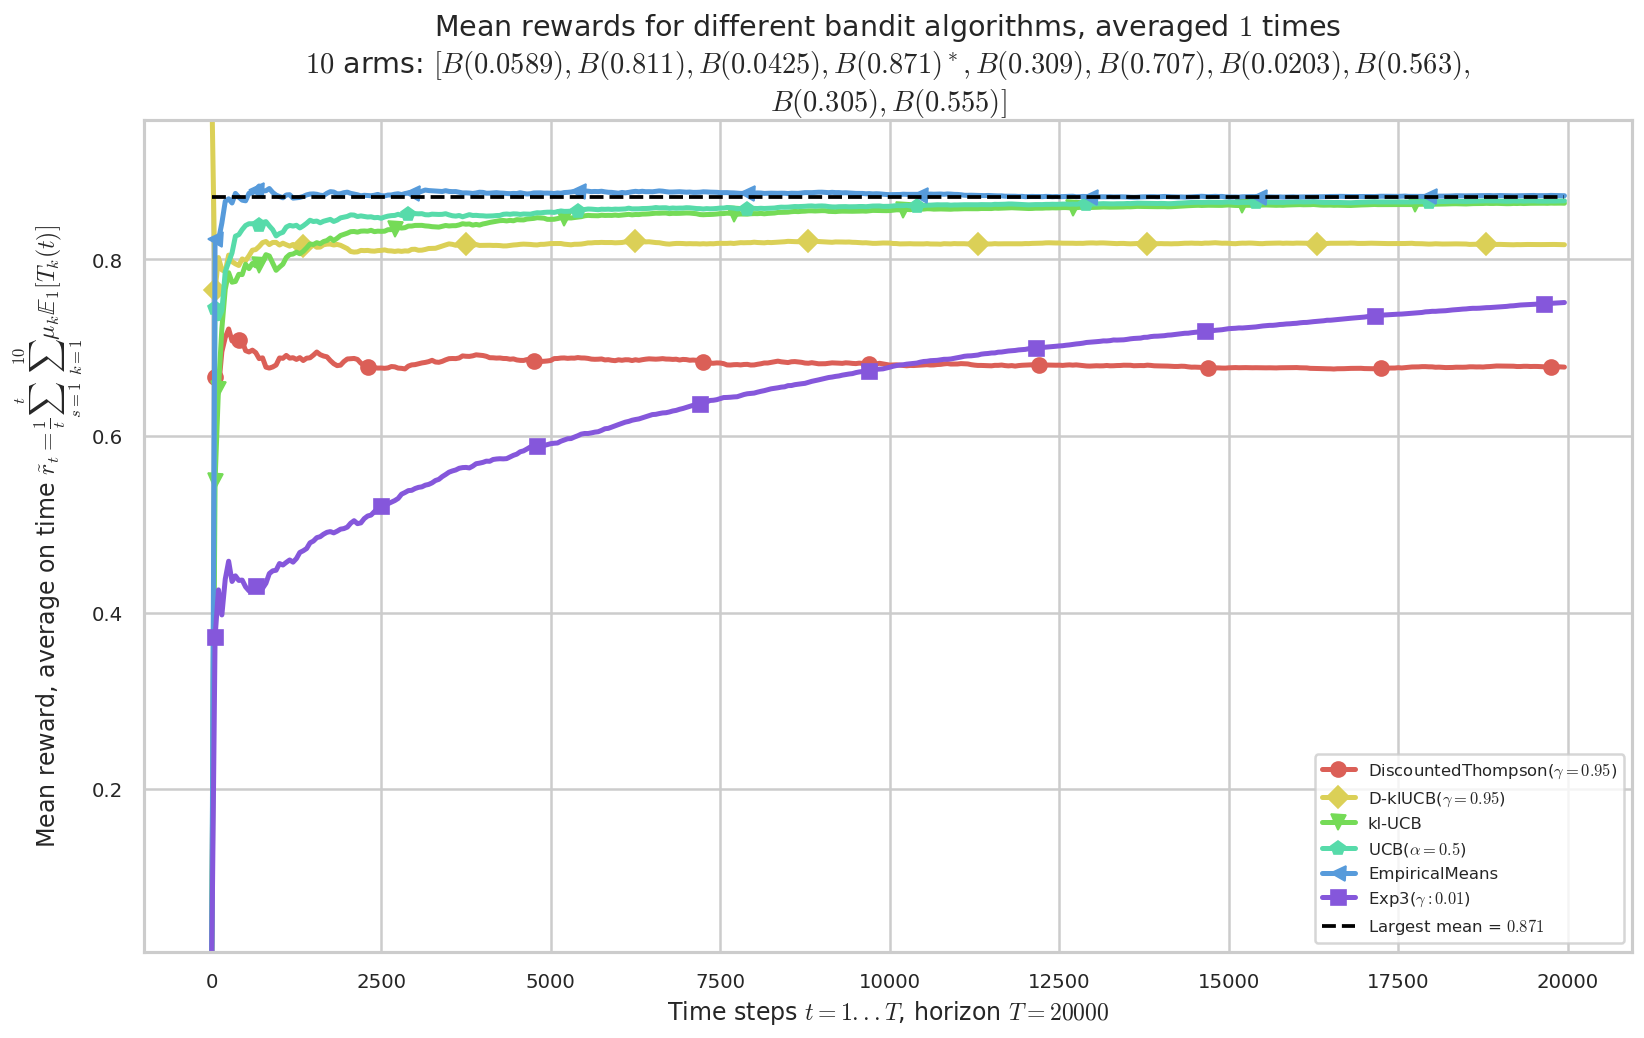

In [17]:
evaluator.printFinalRanking(0)
evaluator.plotRegrets(0, meanReward=True)

Теперь соберём кортеж для нашего трансформера - $(r_i, a_i, t_i)$ и $(r_{i+1}, a_{i+1})$

In [38]:
rewards = np.zeros((6, 20000))
for i in range(6):
    rewards[i] = evaluator.getRewards(i)

In [30]:
actions = evaluator.allPulls[0].argmax(1)
actions

array([[4, 1, 9, ..., 9, 8, 1],
       [4, 3, 5, ..., 1, 1, 1],
       [9, 4, 2, ..., 3, 3, 3],
       [9, 4, 2, ..., 3, 3, 3],
       [6, 7, 0, ..., 3, 3, 3],
       [8, 1, 5, ..., 3, 3, 3]])

Дальше немножко тонкий момент. Нужно собрать все окна от начала до конца в пределах каждого рана и не залезть случайно в другой. Это несложно сделать страйдами. Сразу определимся с длиной эпизода. Для бандитов она не уточняется, так что я возьму от балды 64, чтобы не было совсем уж долго

In [22]:
def window_stack(array, window_size=(1, 3)):
    return np.vstack(np.lib.stride_tricks.sliding_window_view(array, window_size))

In [54]:
# позиции задаидим ручками, не будем лениться
time_steps = np.repeat(np.arange(20000)[None, :], repeats=6, axis=0)
time_steps

array([[    0,     1,     2, ..., 19997, 19998, 19999],
       [    0,     1,     2, ..., 19997, 19998, 19999],
       [    0,     1,     2, ..., 19997, 19998, 19999],
       [    0,     1,     2, ..., 19997, 19998, 19999],
       [    0,     1,     2, ..., 19997, 19998, 19999],
       [    0,     1,     2, ..., 19997, 19998, 19999]])

Во-первых, сразу отрежем концы, чтобы было из чего собирать таргет

In [75]:
dataset = {}

for key, array in zip(["rewards", "actions", "time_steps"], [rewards, actions, time_steps]):
    dataset[key] = window_stack(array[:, :-64], (1, 64)).squeeze(1)
    dataset["future_"+key] = window_stack(array[:, 64:], (1, 64))[:, :, 0]
    
del dataset["future_time_steps"]
gc.collect()

0

In [79]:
dataset = Dataset.from_dict(dataset)

In [165]:
import git
from pathlib import Path

repo = git.Repo(".", search_parent_directories=True).working_tree_dir

In [167]:
Path(DATASET_DIR, "odd_set")

PosixPath('/home/ivanov.dko/projects/distilrl/outputs/datasets/odd_set')

In [164]:
from distilrl.constants import DATASET_DIR

dataset.save_to_disk(Path(DATASET_DIR, "odd_set"))

AttributeError: 'numpy.ndarray' object has no attribute 'save_to_disk'

In [ ]:
for name, dataset in zip(["odd_set", "even_set", "uniform_set"], [odd_set, even_set, uniform_set]):

    envs = [{"arm_type": arm, "params": params} for arm, params in zip([arm_cfg["arm_type"] for _ in range(n_runs)], dataset)]
    env_cfg["environment"] = envs
    env_cfg["policies"] = policies
    
    # %%capture
    seed_everything(42)

    evaluator = Evaluator(env_cfg)
    for idx, env in enumerate(evaluator.envs):
        evaluator.startOneEnv(idx, env)
        
    rewards = np.zeros((len(policies), env_cfg["horizon"]))
    for i in range(len(policies)):
        rewards[i] = evaluator.getRewards(i)
    actions = evaluator.allPulls[0].argmax(1)
    time_steps = np.repeat(np.arange(env_cfg["horizon"])[None, :], repeats=len(policies), axis=0)
    
    dataset = {}

    for key, array in zip(["rewards", "actions", "time_steps"], [rewards, actions, time_steps]):
        dataset[key] = window_stack(array[:, :-64], (1, 64)).squeeze(1)
        dataset["future_"+key] = window_stack(array[:, 64:], (1, 64))[:, :, 0]
        
    del dataset["future_time_steps"]
    gc.collect()
    
    dataset= Dataset.from_dict(dataset)
    dataset = dataset.select(np.random.choice(len(dataset), size=(60000)))
    dataset.save_to_disk(Path(DATASET_DIR, name))

In [170]:
rewards = np.zeros((len(policies), env_cfg["horizon"]))
for i in range(len(policies)):
    rewards[i] = evaluator.getRewards(i)
actions = evaluator.allPulls[0].argmax(1)
time_steps = np.repeat(np.arange(env_cfg["horizon"])[None, :], repeats=len(policies), axis=0)

dataset = {}

for key, array in zip(["rewards", "actions", "time_steps"], [rewards, actions, time_steps]):
    dataset[key] = window_stack(array[:, :-64], (1, 64)).squeeze(1)
    dataset["future_"+key] = window_stack(array[:, 64:], (1, 64))[:, :, 0]
    
del dataset["future_time_steps"]
gc.collect()

dataset= Dataset.from_dict(dataset)
dataset = dataset.select(np.random.choice(len(dataset), size=(60000)))
dataset.save_to_disk(Path(DATASET_DIR, name))

AttributeError: 'dict' object has no attribute 'select'

In [155]:
env_cfg["horizon"]

20000